In [1]:
import os
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.applications import MobileNetV2
from keras import Sequential
from keras.utils import image_dataset_from_directory
from keras.layers import Dense,BatchNormalization,Dropout,GlobalAveragePooling2D
from keras.regularizers import L2
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report, confusion_matrix,accuracy_score

In [26]:
test_path = r"C:\Users**\user\OneDrive - REVA University\Projects\BrainVision-AI\Dataset\classification_task\test"
train_path = r"C:\Users**\user\OneDrive - REVA University\Projects\BrainVision-AI\Dataset\classification_task\train"

In [3]:
BATCH_SIZE = 64
EPOCH = 30
SIZE = (224,224)

In [4]:
train_datagen = ImageDataGenerator(rescale=1/255.0)
val_datagen = ImageDataGenerator(rescale=1/255.0)
test_datagen = ImageDataGenerator(rescale=1/255.0)

In [13]:
train_dataset = image_dataset_from_directory(
    train_path,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=SIZE,
    batch_size=BATCH_SIZE,
)
val_dataset = image_dataset_from_directory(
    train_path,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=SIZE,
    batch_size=BATCH_SIZE
)

Found 5000 files belonging to 4 classes.
Using 4000 files for training.
Found 5000 files belonging to 4 classes.
Using 1000 files for validation.


In [14]:
class_names = train_dataset.class_names
num_classes = len(class_names)

In [15]:
test_dataset = image_dataset_from_directory(
    test_path,
    image_size=SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 1000 files belonging to 4 classes.


In [16]:
base_model = MobileNetV2(input_shape=(224,224,3),include_top=False,weights="imagenet")
base_model.trainable = False

In [17]:
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(128, activation="relu"),
    Dropout(0.4),
    # Dense(64,activation="relu"),
    # Dropout(0.2),
    Dense(32,activation="relu"),
    Dropout(0.3),
    # Dense(16,activation="relu"),
    # Dropout(0.2),
    Dense(8,activation="relu"),
    Dense(num_classes, activation="softmax")
])

In [24]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy","recall"]
)

In [12]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    mode="min",
    restore_best_weights=True,
    verbose=1
)

In [19]:
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCH,
    callbacks=[early_stopping]
)

Epoch 1/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 106s 1s/step - accuracy: 0.5760 - loss: 0.9787 - val_accuracy: 0.7320 - val_loss: 0.6100
Epoch 2/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 92s 1s/step - accuracy: 0.7362 - loss: 0.6609 - val_accuracy: 0.8410 - val_loss: 0.4588
Epoch 3/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 90s 1s/step - accuracy: 0.7815 - loss: 0.5414 - val_accuracy: 0.8630 - val_loss: 0.3905
Epoch 4/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 98s 2s/step - accuracy: 0.8163 - loss: 0.4802 - val_accuracy: 0.8760 - val_loss: 0.3541
Epoch 5/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 94s 2s/step - accuracy: 0.8475 - loss: 0.4125 - val_accuracy: 0.8800 - val_loss: 0.3303
Epoch 6/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 93s 1s/step - accuracy: 0.8512 - loss: 0.3895 - val_accuracy: 0.8830 - val_loss: 0.3226
Epoch 7/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 86s 1s/step - accuracy: 0.8620 - loss: 0.3653 - val_accuracy: 0.8740 - val_loss: 0.3702
Epoch 8/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 92s 1s/step - accuracy: 0.8733 - loss: 0.3381 - val_accuracy: 0.8940 - val_loss

In [21]:
accuracy_score(y_true,y_pred)

0.878

In [20]:
y_true = []
y_pred = []

for images, labels in test_dataset:
    predictions = model.predict(images, verbose=0)
    predicted_classes = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_classes)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

              precision    recall  f1-score   support

      glioma       0.86      0.80      0.83       254
  meningioma       0.81      0.80      0.80       306
    no_tumor       0.88      0.99      0.93       140
   pituitary       0.96      0.98      0.97       300

    accuracy                           0.88      1000
   macro avg       0.88      0.89      0.88      1000
weighted avg       0.88      0.88      0.88      1000



In [22]:
cm = confusion_matrix(y_true,y_pred)

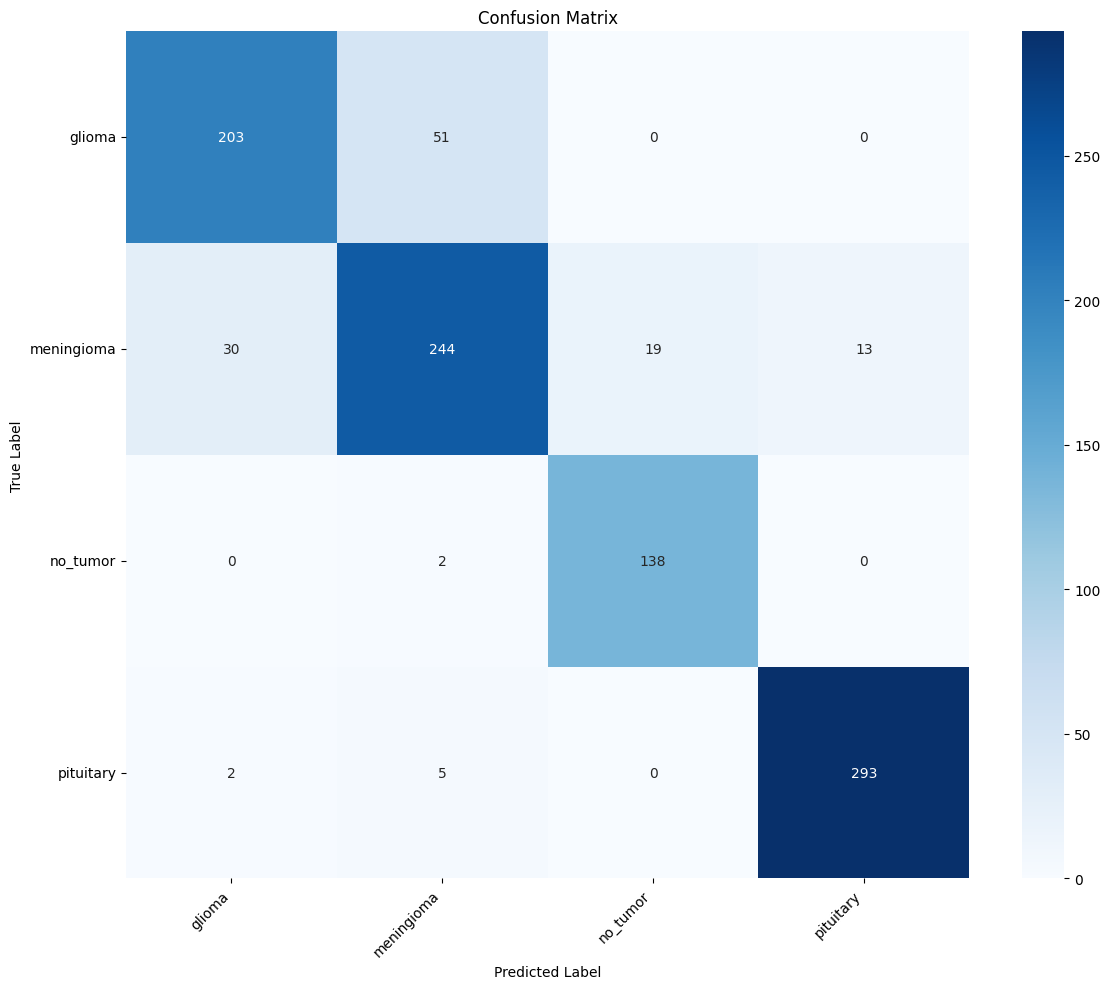

In [23]:
plt.figure(figsize=(12, 10))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [27]:
os.makedirs("Models", exist_ok=True)
model.save("Models/brain_vision_ai.keras")